# Fit Prophet model to the time dependency of cumulative sales for each store.

11:55:14 - cmdstanpy - INFO - Chain [1] start processing
11:55:15 - cmdstanpy - INFO - Chain [1] done processing
11:55:15 - cmdstanpy - INFO - Chain [1] start processing
11:55:15 - cmdstanpy - INFO - Chain [1] done processing
11:55:16 - cmdstanpy - INFO - Chain [1] start processing
11:55:16 - cmdstanpy - INFO - Chain [1] done processing
11:55:16 - cmdstanpy - INFO - Chain [1] start processing
11:55:16 - cmdstanpy - INFO - Chain [1] done processing
11:55:16 - cmdstanpy - INFO - Chain [1] start processing
11:55:17 - cmdstanpy - INFO - Chain [1] done processing
11:55:17 - cmdstanpy - INFO - Chain [1] start processing
11:55:17 - cmdstanpy - INFO - Chain [1] done processing
11:55:17 - cmdstanpy - INFO - Chain [1] start processing
11:55:17 - cmdstanpy - INFO - Chain [1] done processing
11:55:18 - cmdstanpy - INFO - Chain [1] start processing
11:55:18 - cmdstanpy - INFO - Chain [1] done processing
11:55:18 - cmdstanpy - INFO - Chain [1] start processing
11:55:18 - cmdstanpy - INFO - Chain [1]

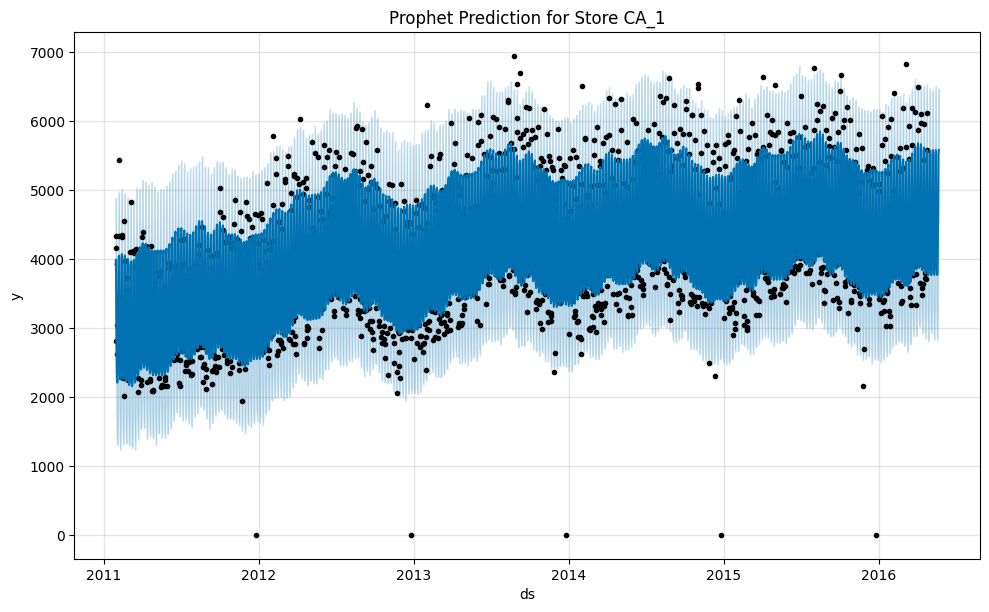

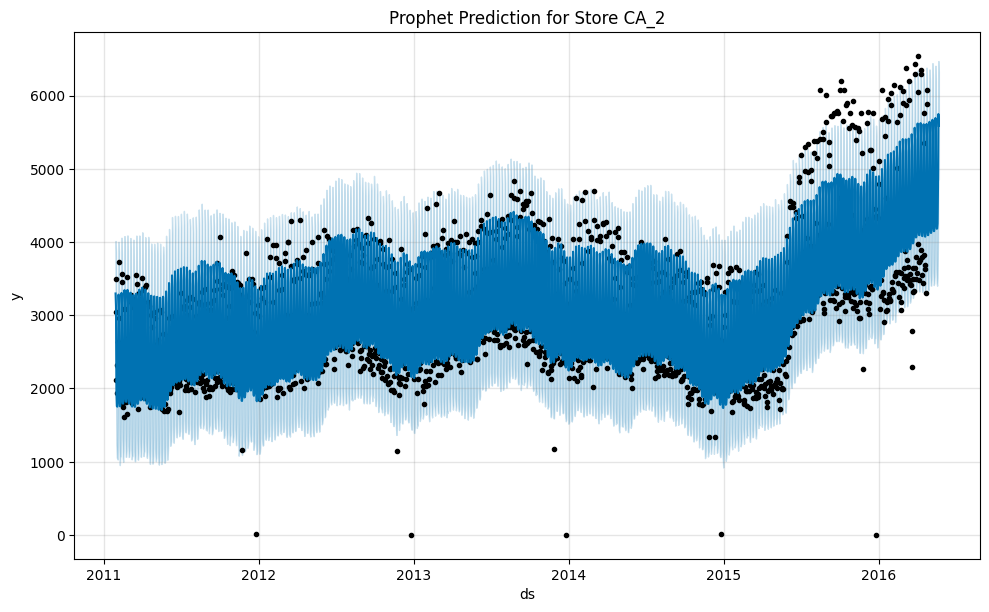

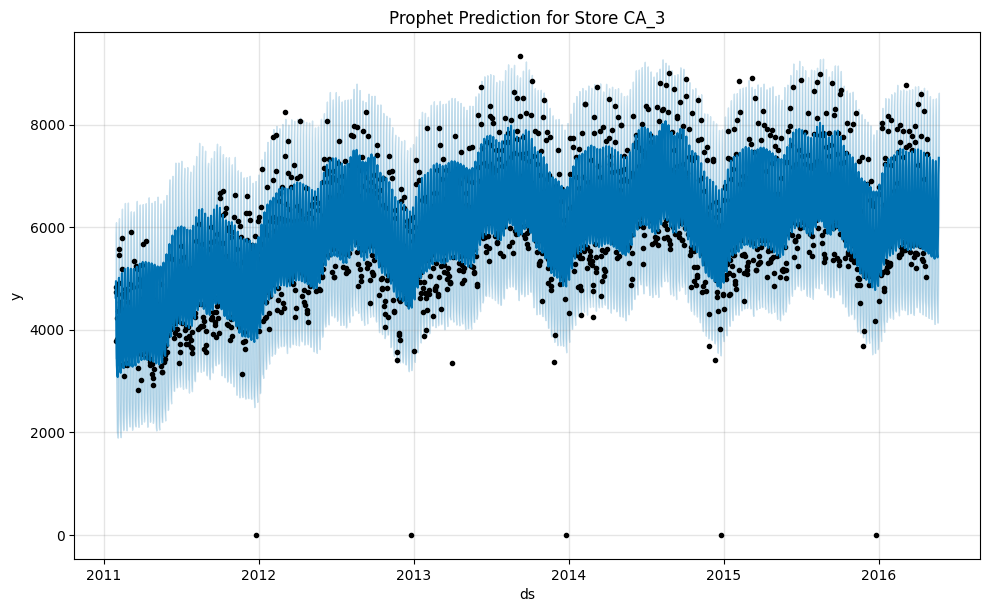

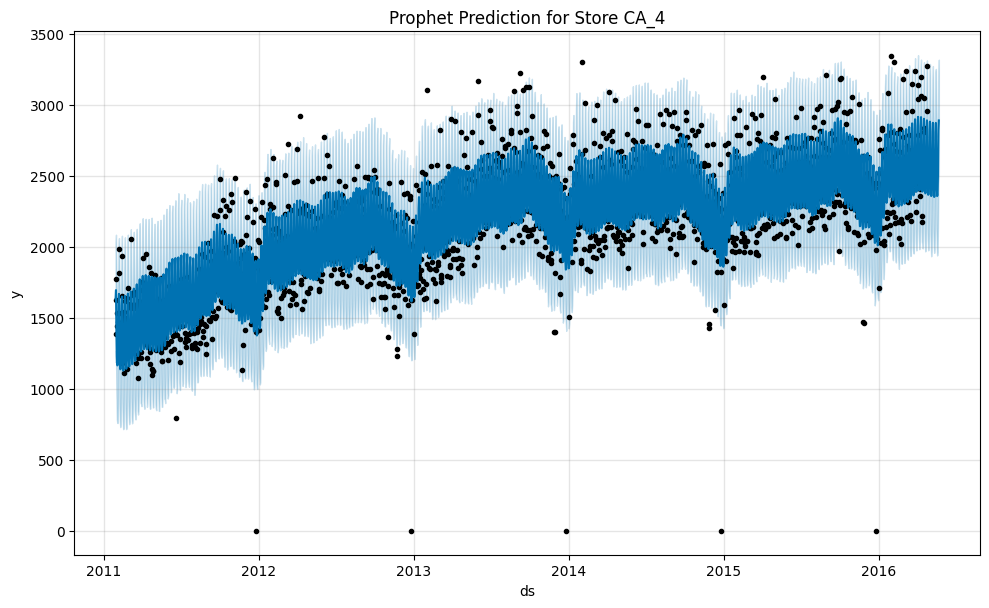

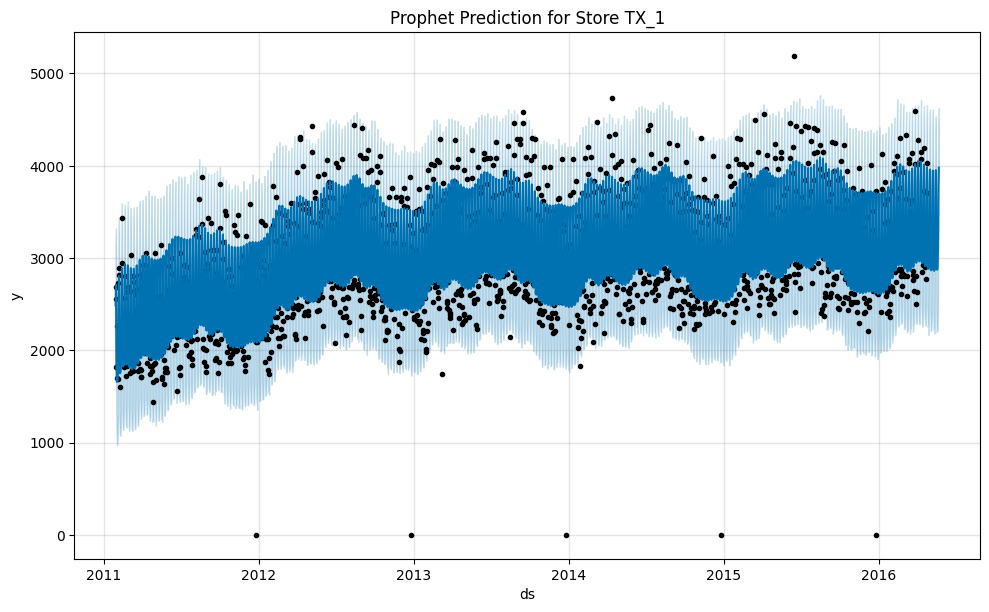

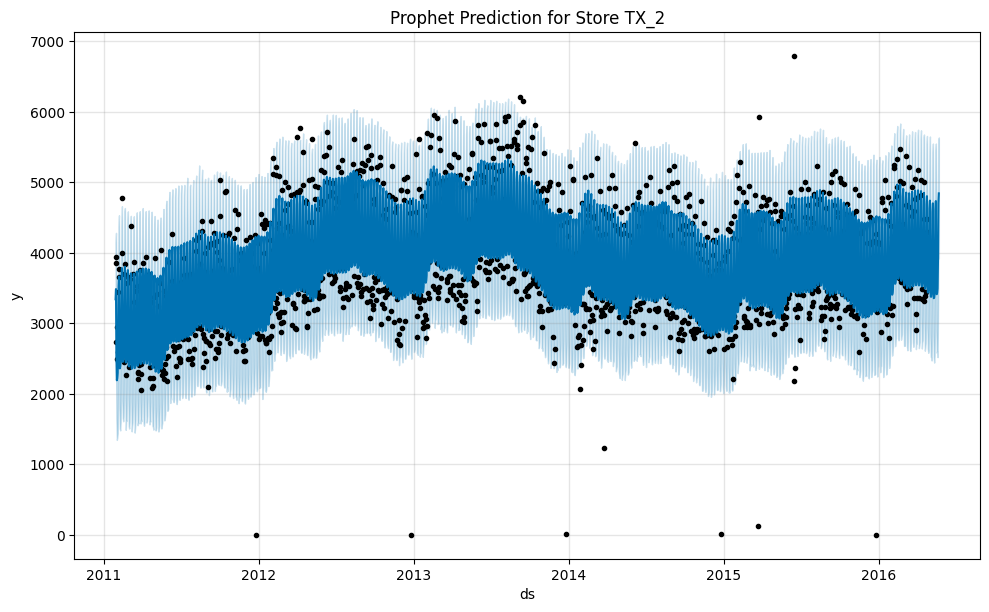

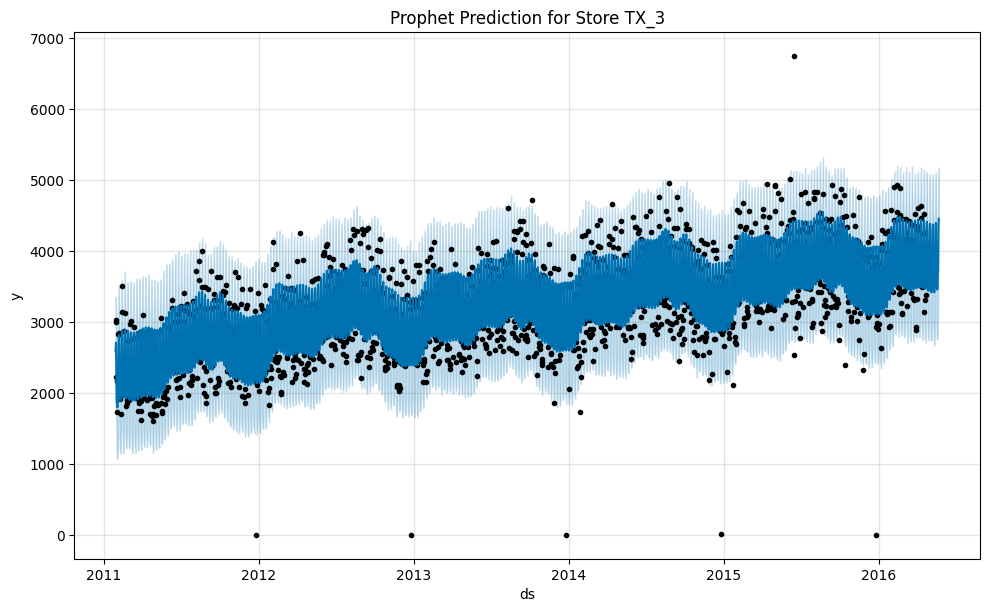

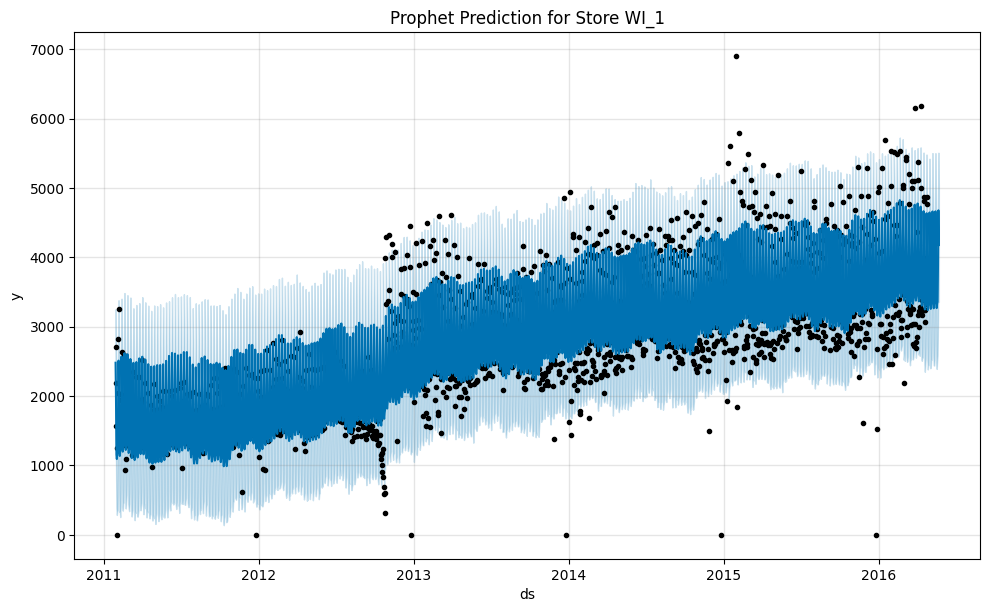

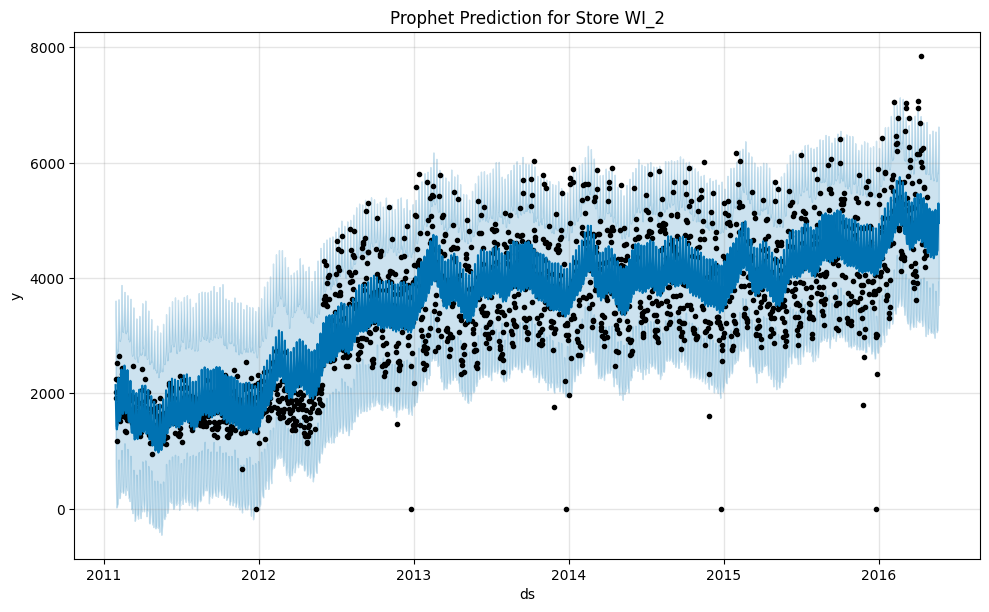

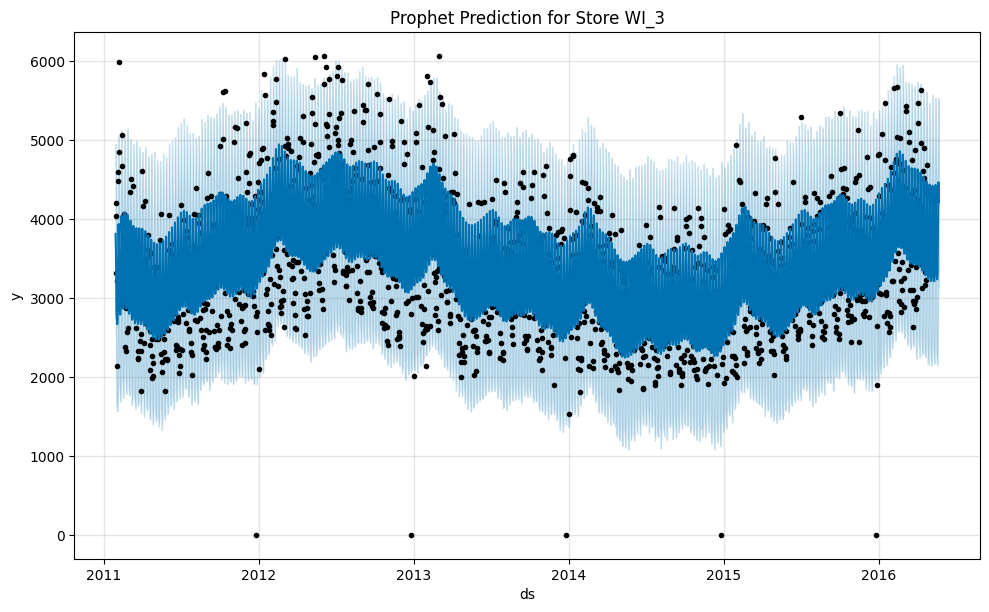

In [71]:
import os
import pandas as pd
from prophet import Prophet
import numpy as np
import matplotlib.pyplot as plt

DATASETS_PATH = os.getenv("DATASETS_PATH") 

df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")

df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")

df_sales_train = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_validation.csv")

df_sales_evaluate = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")

store_ids = df_sales_train['store_id'].unique()

store_dfs = {}

store_sums_train = {}

store_sums_evaluate = {}

store_sell_prices = {}

for store in store_ids:
    
    df_store_train = df_sales_train[df_sales_train['store_id'] == store].copy()
    day_cols_train = [col for col in df_store_train.columns if col.startswith('d_')]
    df_sum_train = df_store_train[day_cols_train].sum(axis=0).reset_index()
    df_sum_train.columns = ['d', 'y']
    store_sums_train[store] = df_sum_train.copy()

    df_store_evaluate = df_sales_evaluate[df_sales_evaluate['store_id'] == store].copy()
    day_cols_evaluate = [col for col in df_store_evaluate.columns if col.startswith('d_')]
    df_sum_evaluate = df_store_evaluate[day_cols_evaluate].sum(axis=0).reset_index()
    df_sum_evaluate.columns = ['d', 'y']
    store_sums_evaluate[store] = df_sum_evaluate.copy()

    df_store_prices = df_sell_prices[df_sell_prices['store_id'] == store].copy()
    store_sell_prices[store] = df_store_prices.copy()
    
    
    df_prophet = df_sum_train.merge(df_calendar[['d','date']], on='d', how='left')
    
    df_prophet = df_prophet[['date','y']].rename(columns={'date':'ds'})
    
    store_dfs[store] = df_prophet.copy()
   

store_models = {} 
for store, df in store_dfs.items(): 
    model = Prophet(interval_width=0.95) 
    model.fit(df) 
    store_models[store] = model

future_days = 28

# Dictionary to store forecasts for each store
store_forecasts = {}

for store_id, df_store in store_dfs.items():
    
    # Get the trained model
    model = store_models[store_id]
    
    # Create future dataframe
    future = model.make_future_dataframe(periods=future_days)
    
    # Predict
    forecast = model.predict(future)
    
    # Optional: plot
    fig = model.plot(forecast)
    plt.title(f"Prophet Prediction for Store {store_id}")
    plt.show()
    
    # Keep only relevant columns
    forecast_store = forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']].copy()
    
    # Add store_id column
    forecast_store['store_id'] = store_id
    
    # Save in dictionary
    store_forecasts[store_id] = forecast_store.copy()


In [72]:
print(store_forecasts)

{'CA_1':              ds   yhat_lower   yhat_upper         yhat store_id
0    2011-01-29  3042.054034  4883.197314  3917.537422     CA_1
1    2011-01-30  3088.801288  4878.745554  3991.203969     CA_1
2    2011-01-31  1721.233049  3715.171693  2725.109736     CA_1
3    2011-02-01  1329.614232  3240.938000  2290.586326     CA_1
4    2011-02-02  1337.196488  3104.651920  2207.502741     CA_1
...         ...          ...          ...          ...      ...
1936 2016-05-18  2829.699837  4742.019523  3769.626355     CA_1
1937 2016-05-19  2886.612370  4761.219532  3808.640561     CA_1
1938 2016-05-20  3621.363915  5397.292823  4471.292615     CA_1
1939 2016-05-21  4575.190654  6476.269208  5517.809955     CA_1
1940 2016-05-22  4659.670725  6459.486164  5583.489589     CA_1

[1941 rows x 5 columns], 'CA_2':              ds   yhat_lower   yhat_upper         yhat store_id
0    2011-01-29  2567.671233  4014.511690  3297.646884     CA_2
1    2011-01-30  2378.946128  3875.816423  3120.281203     CA

In [73]:
print(store_sums_train)

{'CA_1':            d     y
0        d_1  4337
1        d_2  4155
2        d_3  2816
3        d_4  3051
4        d_5  2630
...      ...   ...
1908  d_1909  3722
1909  d_1910  3709
1910  d_1911  4387
1911  d_1912  5577
1912  d_1913  6113

[1913 rows x 2 columns], 'CA_2':            d     y
0        d_1  3494
1        d_2  3046
2        d_3  2121
3        d_4  2324
4        d_5  1942
...      ...   ...
1908  d_1909  3691
1909  d_1910  3303
1910  d_1911  4457
1911  d_1912  5884
1912  d_1913  6082

[1913 rows x 2 columns], 'CA_3':            d     y
0        d_1  4739
1        d_2  4827
2        d_3  3785
3        d_4  4232
4        d_5  3817
...      ...   ...
1908  d_1909  5235
1909  d_1910  5018
1910  d_1911  5623
1911  d_1912  7419
1912  d_1913  7721

[1913 rows x 2 columns], 'CA_4':            d     y
0        d_1  1625
1        d_2  1777
2        d_3  1386
3        d_4  1440
4        d_5  1536
...      ...   ...
1908  d_1909  2500
1909  d_1910  2458
1910  d_1911  2628
1911  d_1912  2

In [74]:
print(store_sums_evaluate)

{'CA_1':            d     y
0        d_1  4337
1        d_2  4155
2        d_3  2816
3        d_4  3051
4        d_5  2630
...      ...   ...
1936  d_1937  3995
1937  d_1938  4136
1938  d_1939  4433
1939  d_1940  5764
1940  d_1941  6289

[1941 rows x 2 columns], 'CA_2':            d     y
0        d_1  3494
1        d_2  3046
2        d_3  2121
3        d_4  2324
4        d_5  1942
...      ...   ...
1936  d_1937  3789
1937  d_1938  4037
1938  d_1939  4751
1939  d_1940  7120
1940  d_1941  6614

[1941 rows x 2 columns], 'CA_3':            d     y
0        d_1  4739
1        d_2  4827
2        d_3  3785
3        d_4  4232
4        d_5  3817
...      ...   ...
1936  d_1937  5375
1937  d_1938  5580
1938  d_1939  5542
1939  d_1940  7073
1940  d_1941  8144

[1941 rows x 2 columns], 'CA_4':            d     y
0        d_1  1625
1        d_2  1777
2        d_3  1386
3        d_4  1440
4        d_5  1536
...      ...   ...
1936  d_1937  2519
1937  d_1938  2544
1938  d_1939  2704
1939  d_1940  3

In [75]:
print(store_sell_prices)

{'CA_1':        store_id        item_id  wm_yr_wk  sell_price
0          CA_1  HOBBIES_1_001     11325        9.58
1          CA_1  HOBBIES_1_001     11326        9.58
2          CA_1  HOBBIES_1_001     11327        8.26
3          CA_1  HOBBIES_1_001     11328        8.26
4          CA_1  HOBBIES_1_001     11329        8.26
...         ...            ...       ...         ...
698407     CA_1    FOODS_3_827     11617        1.00
698408     CA_1    FOODS_3_827     11618        1.00
698409     CA_1    FOODS_3_827     11619        1.00
698410     CA_1    FOODS_3_827     11620        1.00
698411     CA_1    FOODS_3_827     11621        1.00

[698412 rows x 4 columns], 'CA_2':         store_id        item_id  wm_yr_wk  sell_price
698412      CA_2  HOBBIES_1_001     11327        8.26
698413      CA_2  HOBBIES_1_001     11328        8.26
698414      CA_2  HOBBIES_1_001     11329        8.26
698415      CA_2  HOBBIES_1_001     11330        8.26
698416      CA_2  HOBBIES_1_001     11331        

In [76]:
result_store_prices = {}
for store in store_ids:
    pivot_prices = store_sell_prices[store].pivot_table(
    index='wm_yr_wk',
    columns='item_id',
    values='sell_price',
    aggfunc='first'
    )
    # Get original item order from sales
    original_items = df_sales_train[df_sales_train['store_id'] == store]['item_id'].tolist()
    
    # Keep only unique (in case duplicates)
    original_items = list(dict.fromkeys(original_items))
    
    # Reindex pivot table
    pivot_prices = pivot_prices.reindex(columns=original_items)
    
    df_day_week = df_calendar[['d','wm_yr_wk']]
    
    result_store_prices[store] = df_day_week.merge(
        pivot_prices.reset_index(),
        on='wm_yr_wk',
        how='left'
    ).set_index('d')
    
    # Drop wm_yr_wk if needed
    result_store_prices[store] = result_store_prices[store].drop(columns='wm_yr_wk', errors='ignore')
    
    # Fill missing
    result_store_prices[store] = result_store_prices[store].fillna(0)

print(result_store_prices)

{'CA_1':         HOBBIES_1_001  HOBBIES_1_002  HOBBIES_1_003  HOBBIES_1_004  \
d                                                                    
d_1              0.00           0.00           0.00           0.00   
d_2              0.00           0.00           0.00           0.00   
d_3              0.00           0.00           0.00           0.00   
d_4              0.00           0.00           0.00           0.00   
d_5              0.00           0.00           0.00           0.00   
...               ...            ...            ...            ...   
d_1965           8.38           3.97           2.97           4.64   
d_1966           8.38           3.97           2.97           4.64   
d_1967           8.38           3.97           2.97           4.64   
d_1968           8.38           3.97           2.97           4.64   
d_1969           8.38           3.97           2.97           4.64   

        HOBBIES_1_005  HOBBIES_1_006  HOBBIES_1_007  HOBBIES_1_008  \
d         

In [77]:
day_cols = [col for col in df_sales_train.columns if col.startswith('d_')]
total_sales_per_item = (
    df_sales_train[day_cols]
    .sum(axis=1)
    .groupby(df_sales_train['item_id'])
    .sum()
)
print(total_sales_per_item)

item_id
FOODS_1_001         12247
FOODS_1_002          7334
FOODS_1_003         13394
FOODS_1_004        129481
FOODS_1_005         22914
                    ...  
HOUSEHOLD_2_512     11555
HOUSEHOLD_2_513      7916
HOUSEHOLD_2_514      3150
HOUSEHOLD_2_515      1121
HOUSEHOLD_2_516      2543
Length: 3049, dtype: int64


In [78]:
item_cat_map = df_sales_train[['item_id', 'cat_id']].drop_duplicates()
sales_with_cat = total_sales_per_item.reset_index(name='total_sales').merge(
    item_cat_map,
    on='item_id',
    how='left'
)
total_sales_per_category = (
    sales_with_cat
    .groupby('cat_id')['total_sales']
    .sum()
)
print(total_sales_per_category)

cat_id
FOODS        45089939
HOBBIES       6124800
HOUSEHOLD    14480670
Name: total_sales, dtype: int64


In [79]:
sales_with_cat['cat_total'] = sales_with_cat['cat_id'].map(total_sales_per_category)

# Compute weights
sales_with_cat['weight'] = (
    sales_with_cat['total_sales'] / sales_with_cat['cat_total']
)
weights_by_cat = {}

for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    df_cat = sales_with_cat[sales_with_cat['cat_id'] == cat]
    
    weights_by_cat[cat] = df_cat.set_index('item_id')['weight']

features_per_store = {}

df_day_week = df_calendar[['d','wm_yr_wk']]

for store in store_ids:
    price_df = result_store_prices[store]
    
    features = pd.DataFrame(index=price_df.index)
    
    for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
        
        weights = weights_by_cat[cat]
        
        # Align columns
        common_items = price_df.columns.intersection(weights.index)
        
        features[f'{cat}_price_index'] = (
            price_df[common_items] @ weights.loc[common_items]
        )
    features_per_store[store]=features.copy()

print(features_per_store)

{'CA_1':         FOODS_price_index  HOBBIES_price_index  HOUSEHOLD_price_index
d                                                                    
d_1              1.456275             1.516160               1.674497
d_2              1.456275             1.516160               1.674497
d_3              1.456275             1.516160               1.674497
d_4              1.456275             1.516160               1.674497
d_5              1.456275             1.516160               1.674497
...                   ...                  ...                    ...
d_1965           2.498240             3.751838               3.902429
d_1966           2.498240             3.751838               3.902429
d_1967           2.498240             3.751838               3.902429
d_1968           2.498341             3.749266               3.901985
d_1969           2.498341             3.749266               3.901985

[1969 rows x 3 columns], 'CA_2':         FOODS_price_index  HOBBIES_price_index 

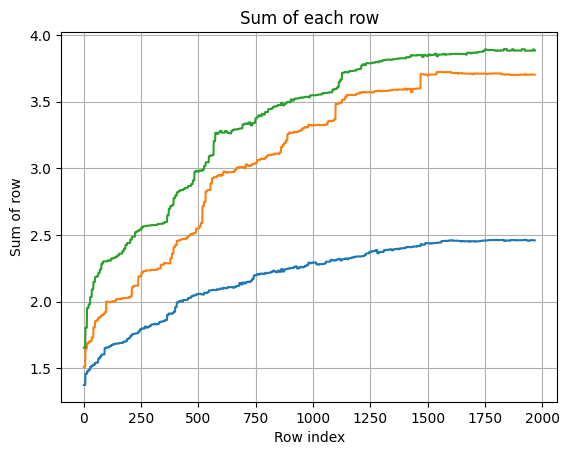

In [80]:
plt.plot(features_per_store['TX_1'].to_numpy())
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row")
plt.grid(True)
plt.show()

In [81]:
calendar = df_calendar.copy()
calendar = calendar[[
    'date', 'd', 'wday', 'month',
    'event_name_1','event_type_1',
    'event_name_2','event_type_2',
    'snap_CA','snap_TX','snap_WI'
]]
calendar['date'] = pd.to_datetime(calendar['date'])

final_dfs = []

for store in store_ids:
    # 1. Forecast
    df_forecast = store_forecasts[store].copy()

    # 2. Price features (d-based)
    df_prices = features_per_store[store].reset_index()  # 'd' becomes column

    # 3. Actual sales (y)
    df_sales = store_sums_train[store].copy()

    # 4. Merge prices + sales
    df = df_prices.merge(df_sales, on='d', how='left')

    # 5. Merge calendar
    df = df.merge(calendar, on='d', how='left')

    # 6. Merge forecast (via date)
    df = df.merge(
        df_forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']],
        left_on='date',
        right_on='ds',
        how='left'
    )
    df.drop(columns='ds', inplace=True)

    # 7. Add store + state
    state = store.split('_')[0]
    df['state'] = state
    df['store_id'] = store

    # 8. SNAP column (state-specific)
    snap_col = f'snap_{state}'
    df['snap'] = df[snap_col]

    # 9. Select final columns
    df = df[[
        'date','wday','month',
        'event_name_1','event_type_1',
        'event_name_2','event_type_2',
        'state','store_id','snap',
        'yhat_lower','yhat_upper','yhat',
        'FOODS_price_index','HOBBIES_price_index','HOUSEHOLD_price_index',
        'y'
    ]]

    final_dfs.append(df)

# Combine all stores — now we have 1941 dates x n stores
final_df = pd.concat(final_dfs, ignore_index=True)

# Fill missing event info
final_df[['event_name_1','event_type_1','event_name_2','event_type_2']] = \
    final_df[['event_name_1','event_type_1','event_name_2','event_type_2']].fillna('None')

# -------------------------------
# Keep first 1941 dates per store for training
# -------------------------------
final_df_train = final_df.groupby('store_id').head(1912).reset_index(drop=True)
final_df_evaluate = final_df.groupby('store_id').head(1941).reset_index(drop=True)

# -------------------------------
# Encode categorical features
# -------------------------------
from sklearn.preprocessing import LabelEncoder

cat_cols = ['event_name_1','event_type_1','event_name_2','event_type_2','state','store_id']
initial_features_train = final_df_train.copy()
initial_features_evaluate = final_df_evaluate.copy()
mappings = {}
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    initial_features_train[col] = le.fit_transform(initial_features_train[col].astype(str))
    initial_features_evaluate[col] = le.fit_transform(initial_features_evaluate[col].astype(str))
    # Save the encoder
    label_encoders[col] = le
    
    # Save mapping as dictionary {original_value: encoded_value}
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# -------------------------------
# Check shapes
# -------------------------------
print("Train shape:", initial_features_train.shape)
print("Evaluation shape:", initial_features_evaluate.shape)
print("Unique states:", initial_features_train['state'].unique())
print("Unique stores:", initial_features_train['store_id'].unique())
print("Unique events 2:", initial_features_train['event_type_1'].unique())
print("State mapping:", mappings['event_name_1'])
print("Store mapping:", mappings['store_id'])

Train shape: (19120, 17)
Evaluation shape: (19410, 17)
Unique states: [0 1 2]
Unique stores: [0 1 2 3 4 5 6 7 8 9]
Unique events 2: [2 4 0 1 3]
State mapping: {'Chanukah End': np.int64(0), 'Christmas': np.int64(1), 'Cinco De Mayo': np.int64(2), 'ColumbusDay': np.int64(3), 'Easter': np.int64(4), 'Eid al-Fitr': np.int64(5), 'EidAlAdha': np.int64(6), "Father's day": np.int64(7), 'Halloween': np.int64(8), 'IndependenceDay': np.int64(9), 'LaborDay': np.int64(10), 'LentStart': np.int64(11), 'LentWeek2': np.int64(12), 'MartinLutherKingDay': np.int64(13), 'MemorialDay': np.int64(14), "Mother's day": np.int64(15), 'NBAFinalsEnd': np.int64(16), 'NBAFinalsStart': np.int64(17), 'NewYear': np.int64(18), 'None': np.int64(19), 'OrthodoxChristmas': np.int64(20), 'OrthodoxEaster': np.int64(21), 'Pesach End': np.int64(22), 'PresidentsDay': np.int64(23), 'Purim End': np.int64(24), 'Ramadan starts': np.int64(25), 'StPatricksDay': np.int64(26), 'SuperBowl': np.int64(27), 'Thanksgiving': np.int64(28), 'Vale

In [82]:
print(initial_features_train)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19115 2016-04-19     4      4            19             2             3   
19116 2016-04-20     5      4            19             2             3   
19117 2016-04-21     6      4            19             2             3   
19118 2016-04-22     7      4            19             2             3   
19119 2016-04-23     1      4            19             2             3   

       event_type_2  state  store_id  snap   yhat_lower   yhat_upper  \
0                 1      0 

In [83]:
print(initial_features_evaluate)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19405 2016-05-18     5      5            19             2             3   
19406 2016-05-19     6      5            19             2             3   
19407 2016-05-20     7      5            19             2             3   
19408 2016-05-21     1      5            19             2             3   
19409 2016-05-22     2      5            19             2             3   

       event_type_2  state  store_id  snap   yhat_lower   yhat_upper  \
0                 1      0 

In [85]:
# Copy original dataframe
features_with_future = initial_features_train.copy()
features_with_future_evaluate = initial_features_evaluate.copy()

# Number of future steps
future_days = 28

future_dfs = []

for store, df_store in features_with_future.groupby('store_id', sort=False):
    df_store = df_store.copy()
    
    # Prepare dictionaries to hold shifted columns
    yhat_cols = {}
    yhatlag_cols = {}
    yhat_lower_cols = {}
    yhat_upper_cols = {}
    y_cols = {}
    ylag_cols = {}
    wday_future = {}
    month_future = {}
    event_name_1_future = {}
    event_type_1_future = {}
    event_name_2_future = {}
    event_type_2_future = {}
    
    for i in range(future_days):
        wday_future[f'wday_{i}'] = df_store['wday'].shift(-(i + 1))
        month_future[f'month_{i}'] = df_store['month'].shift(-(i + 1))
        event_name_1_future[f'event_name_1_{i}'] = df_store['event_name_1'].shift(-(i + 1))
        event_type_1_future[f'event_type_1_{i}'] = df_store['event_type_1'].shift(-(i + 1))
        event_name_2_future[f'event_name_2_{i}'] = df_store['event_name_2'].shift(-(i + 1))
        event_type_2_future[f'event_type_2_{i}'] = df_store['event_type_2'].shift(-(i + 1))
        yhat_cols[f'yhat_{i}'] = df_store['yhat'].shift(-(i + 1))
        yhatlag_cols[f'yhatlag_{i}'] = df_store['yhat'].shift((i + 1))
        yhat_lower_cols[f'yhat_lower_{i}'] = df_store['yhat_lower'].shift(-(i + 1))
        yhat_upper_cols[f'yhat_upper_{i}'] = df_store['yhat_upper'].shift(-(i + 1))
        ylag_cols[f'ylag_{i}'] = df_store['y'].shift(i + 1)
        y_cols[f'y_{i}'] = df_store['y'].shift(-(i + 1))
    
    # Concatenate all new columns at once
    future_shifts = pd.concat([
        pd.DataFrame(wday_future),
        pd.DataFrame(month_future),
        pd.DataFrame(event_name_1_future),
        pd.DataFrame(event_type_1_future),
        pd.DataFrame(yhatlag_cols),
        pd.DataFrame(yhat_cols),
        pd.DataFrame(yhat_lower_cols),
        pd.DataFrame(yhat_upper_cols),
        pd.DataFrame(ylag_cols),
        pd.DataFrame(y_cols)
    ], axis=1)
    
    # Join with original df_store
    df_store = pd.concat([df_store, future_shifts], axis=1)
    
    future_dfs.append(df_store)

# Concatenate all stores
features_with_future = pd.concat(future_dfs, ignore_index=True)

print(features_with_future)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19115 2016-04-19     4      4            19             2             3   
19116 2016-04-20     5      4            19             2             3   
19117 2016-04-21     6      4            19             2             3   
19118 2016-04-22     7      4            19             2             3   
19119 2016-04-23     1      4            19             2             3   

       event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                 1     

In [86]:
future_dfs_evaluate = []
future_dfs = []
for store, df_store in features_with_future_evaluate.groupby('store_id', sort=False):
    df_store = df_store.copy()
    
    # Prepare dictionaries to hold shifted columns
    yhat_cols = {}
    yhatlag_cols = {}
    yhat_lower_cols = {}
    yhat_upper_cols = {}
    y_cols = {}
    ylag_cols = {}
    wday_future = {}
    month_future = {}
    event_name_1_future = {}
    event_type_1_future = {}
    event_name_2_future = {}
    event_type_2_future = {}
    
    for i in range(future_days):
        wday_future[f'wday_{i}'] = df_store['wday'].shift(-(i + 1))
        month_future[f'month_{i}'] = df_store['month'].shift(-(i + 1))
        event_name_1_future[f'event_name_1_{i}'] = df_store['event_name_1'].shift(-(i + 1))
        event_type_1_future[f'event_type_1_{i}'] = df_store['event_type_1'].shift(-(i + 1))
        event_name_2_future[f'event_name_2_{i}'] = df_store['event_name_2'].shift(-(i + 1))
        event_type_2_future[f'event_type_2_{i}'] = df_store['event_type_2'].shift(-(i + 1))
        yhat_cols[f'yhat_{i}'] = df_store['yhat'].shift(-(i + 1))
        yhatlag_cols[f'yhatlag_{i}'] = df_store['yhat'].shift((i + 1))
        yhat_lower_cols[f'yhat_lower_{i}'] = df_store['yhat_lower'].shift(-(i + 1))
        yhat_upper_cols[f'yhat_upper_{i}'] = df_store['yhat_upper'].shift(-(i + 1))
        ylag_cols[f'ylag_{i}'] = df_store['y'].shift(i + 1)
        y_cols[f'y_{i}'] = df_store['y'].shift(-(i + 1))
    
    # Concatenate all new columns at once
    future_shifts = pd.concat([
        pd.DataFrame(wday_future),
        pd.DataFrame(month_future),
        pd.DataFrame(event_name_1_future),
        pd.DataFrame(event_type_1_future),
        pd.DataFrame(yhatlag_cols),
        pd.DataFrame(yhat_cols),
        pd.DataFrame(yhat_lower_cols),
        pd.DataFrame(yhat_upper_cols),
        pd.DataFrame(ylag_cols),
        pd.DataFrame(y_cols)
    ], axis=1)
    
    # Join with original df_store
    df_store = pd.concat([df_store, future_shifts], axis=1)
    
    future_dfs.append(df_store)

# Concatenate all stores
features_with_future_evaluate = pd.concat(future_dfs, ignore_index=True)

print(features_with_future_evaluate)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19405 2016-05-18     5      5            19             2             3   
19406 2016-05-19     6      5            19             2             3   
19407 2016-05-20     7      5            19             2             3   
19408 2016-05-21     1      5            19             2             3   
19409 2016-05-22     2      5            19             2             3   

       event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                 1     

In [87]:
print(list(features_with_future.columns))


['date', 'wday', 'month', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'state', 'store_id', 'snap', 'yhat_lower', 'yhat_upper', 'yhat', 'FOODS_price_index', 'HOBBIES_price_index', 'HOUSEHOLD_price_index', 'y', 'wday_0', 'wday_1', 'wday_2', 'wday_3', 'wday_4', 'wday_5', 'wday_6', 'wday_7', 'wday_8', 'wday_9', 'wday_10', 'wday_11', 'wday_12', 'wday_13', 'wday_14', 'wday_15', 'wday_16', 'wday_17', 'wday_18', 'wday_19', 'wday_20', 'wday_21', 'wday_22', 'wday_23', 'wday_24', 'wday_25', 'wday_26', 'wday_27', 'month_0', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'month_13', 'month_14', 'month_15', 'month_16', 'month_17', 'month_18', 'month_19', 'month_20', 'month_21', 'month_22', 'month_23', 'month_24', 'month_25', 'month_26', 'month_27', 'event_name_1_0', 'event_name_1_1', 'event_name_1_2', 'event_name_1_3', 'event_name_1_4', 'event_name_1_5', 'event_name_1_6', 'event_name_1_7', 'ev

In [88]:
features_with_labels = features_with_future.copy()
features_with_labels = features_with_labels.drop('date', axis=1)

features_with_labels_evaluate = features_with_future_evaluate.copy()

features_with_labels_train = features_with_labels.sample(frac=0.8, random_state=42)
features_with_labels_test = features_with_labels.drop(features_with_labels_train.index)

features_with_labels_train = features_with_labels_train.reset_index(drop=True)
features_with_labels_test = features_with_labels_test.reset_index(drop=True)

print(features_with_labels_train)


       wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
0         1      6            19             2             3             1   
1         7      7            19             2             3             1   
2         5     11            19             2             3             1   
3         3      9            10             1             3             1   
4         4     11            19             2             3             1   
...     ...    ...           ...           ...           ...           ...   
15291     1      6            19             2             3             1   
15292     2      6            25             3             3             1   
15293     3      1            19             2             3             1   
15294     5      5            19             2             3             1   
15295     1      4            19             2             3             1   

       state  store_id  snap   yhat_lower  ...    y_18    y_19 

In [89]:
print(features_with_labels_evaluate)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19405 2016-05-18     5      5            19             2             3   
19406 2016-05-19     6      5            19             2             3   
19407 2016-05-20     7      5            19             2             3   
19408 2016-05-21     1      5            19             2             3   
19409 2016-05-22     2      5            19             2             3   

       event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                 1     

In [36]:
print(features_with_labels_test)

      wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
0        3      2            19             2             3             1   
1        5      2            19             2             3             1   
2        7      2            19             2             3             1   
3        3      2            29             0             3             1   
4        5      2            19             2             3             1   
...    ...    ...           ...           ...           ...           ...   
3877     3      5            19             2             3             1   
3878     2      5            19             2             3             1   
3879     3      5            19             2             3             1   
3880     7      5            19             2             3             1   
3881     2      5            19             2             3             1   

      state  store_id  snap   yhat_lower  ...    y_18    y_19    y_20    y_

In [90]:
# Columns for future labels
label_cols = [f'y_{i}' for i in range(28)]

# Drop rows with NaN in any of the label columns
features_with_labels_clean = features_with_labels.dropna(subset=label_cols).reset_index(drop=True)

features_with_labels_evaluate_clean = features_with_labels_evaluate.dropna(subset=label_cols).reset_index(drop=True)

# Split into train/test randomly
features_train = features_with_labels_clean.sample(frac=0.8, random_state=42).reset_index(drop=True)
labels_train = features_train[label_cols]
features_train = features_train.drop(columns=label_cols)

features_test = features_with_labels_clean.drop(features_train.index).reset_index(drop=True)
labels_test = features_test[label_cols]
features_test = features_test.drop(columns=label_cols)

print(features_train)

       wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
0         6     11            19             2             3             1   
1         5     10            19             2             3             1   
2         7      5            19             2             3             1   
3         5     11            19             2             3             1   
4         7      1            18             1             3             1   
...     ...    ...           ...           ...           ...           ...   
15067     1     11            19             2             3             1   
15068     1      3            19             2             3             1   
15069     2      5            21             3             0             0   
15070     1      4            19             2             3             1   
15071     6      6            19             2             3             1   

       state  store_id  snap   yhat_lower  ...  ylag_18  ylag_1

In [92]:
print(labels_train)

          y_0     y_1     y_2     y_3     y_4     y_5     y_6     y_7     y_8  \
0      4066.0  4790.0  5236.0  3606.0  3433.0  3020.0  3430.0  3452.0  4758.0   
1      1554.0  1725.0  2374.0  2317.0  1615.0  1591.0  1613.0  1741.0  1846.0   
2      2634.0  2323.0  2572.0  2362.0  2052.0  2328.0  2140.0  2251.0  2793.0   
3      3319.0  4048.0  5278.0  5857.0  3928.0  3347.0  3198.0  3330.0  4143.0   
4      4794.0  5101.0  3591.0  3079.0  3261.0  3483.0  3920.0  6081.0  5682.0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
15067  4080.0  2783.0  3152.0  3235.0  2820.0  2477.0  3269.0  3302.0  2574.0   
15068  3352.0  6219.0  6163.0  6024.0  5419.0  6548.0  6971.0  7769.0  5897.0   
15069  6920.0  5839.0  5429.0  5726.0  6021.0  7547.0  6384.0  6371.0  6192.0   
15070  4065.0  3376.0  3002.0  3125.0  3309.0  3428.0  4107.0  3958.0  3479.0   
15071  2599.0  3005.0  2794.0  2297.0  2185.0  2066.0  2201.0  2389.0  2578.0   

          y_9  ...    y_18 

In [91]:
print(features_with_labels_evaluate_clean)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
18845 2016-03-23     5      3            19             2             3   
18846 2016-03-24     6      3            24             3             3   
18847 2016-03-25     7      3            19             2             3   
18848 2016-03-26     1      3            19             2             3   
18849 2016-03-27     2      3             4             0             3   

       event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                 1     

In [93]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

"""
# -------------------------
# RandomForest training (as before)
# -------------------------
rf = RandomForestRegressor(n_estimators=200, max_depth=25, random_state=42, n_jobs=-1)
rf.fit(features_train, labels_train)

labels_train_pred_rf = rf.predict(features_train)
labels_test_pred_rf = rf.predict(features_test)

# Compute RMSE %
rmse_train_rf = np.sqrt(np.mean((labels_train - labels_train_pred_rf) ** 2, axis=0))
rmse_test_rf = np.sqrt(np.mean((labels_test - labels_test_pred_rf) ** 2, axis=0))

mean_rmse_train_rf_pct = rmse_train_rf.mean() / labels_train.values.mean() * 100
mean_rmse_test_rf_pct = rmse_test_rf.mean() / labels_test.values.mean() * 100

print(f"RandomForest Train RMSE%: {mean_rmse_train_rf_pct:.2f}%")
print(f"RandomForest Test RMSE%: {mean_rmse_test_rf_pct:.2f}%")
"""

#Comment out not to execute each time
"""
# -------------------------
# XGBoost training (one model per horizon)
# -------------------------
future_horizons = labels_train.shape[1]
xgb_models = []
labels_train_pred_xgb = np.zeros_like(labels_train)
labels_test_pred_xgb = np.zeros_like(labels_test)

for i in range(future_horizons):
    model = xgb.XGBRegressor(
        n_estimators=110,
        max_depth=12,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(features_train, labels_train.iloc[:, i])
    xgb_models.append(model)
    
    labels_train_pred_xgb[:, i] = model.predict(features_train)
    labels_test_pred_xgb[:, i] = model.predict(features_test)
    print(str(i)+' out of '+ str(future_horizons))

# Compute RMSE %
rmse_train_xgb = np.sqrt(np.mean((labels_train - labels_train_pred_xgb) ** 2, axis=0))
rmse_test_xgb = np.sqrt(np.mean((labels_test - labels_test_pred_xgb) ** 2, axis=0))

mean_rmse_train_xgb_pct = rmse_train_xgb.mean() / labels_train.values.mean() * 100
mean_rmse_test_xgb_pct = rmse_test_xgb.mean() / labels_test.values.mean() * 100

print(f"XGBoost Train RMSE%: {mean_rmse_train_xgb_pct:.2f}%")
print(f"XGBoost Test RMSE%: {mean_rmse_test_xgb_pct:.2f}%")
"""


0 out of 28
1 out of 28
2 out of 28
3 out of 28
4 out of 28
5 out of 28
6 out of 28
7 out of 28
8 out of 28
9 out of 28
10 out of 28
11 out of 28
12 out of 28
13 out of 28
14 out of 28
15 out of 28
16 out of 28
17 out of 28
18 out of 28
19 out of 28
20 out of 28
21 out of 28
22 out of 28
23 out of 28
24 out of 28
25 out of 28
26 out of 28
27 out of 28
XGBoost Train RMSE%: 1.59%
XGBoost Test RMSE%: 5.75%


In [95]:
import os

save_dir = "xgb_models_28d"
os.makedirs(save_dir, exist_ok=True)

import joblib

"""
for i, model in enumerate(xgb_models):
    filepath = os.path.join(save_dir, f"xgb_model_h{i}.pkl")
    joblib.dump(model, filepath)
"""

loaded_models = []

for i in range(future_horizons):
    filepath = os.path.join(save_dir, f"xgb_model_h{i}.pkl")
    model = joblib.load(filepath)
    loaded_models.append(model)

future_horizons = len(loaded_models)

# Initialize prediction array
labels_test_pred_xgb = np.zeros((features_test.shape[0], future_horizons))

# Generate predictions
for i, model in enumerate(loaded_models):
    labels_test_pred_xgb[:, i] = model.predict(features_test)

rmse_test_xgb = np.sqrt(
    np.mean((labels_test.values - labels_test_pred_xgb) ** 2, axis=0)
)

mean_rmse_test_xgb_pct = rmse_test_xgb.mean() / labels_test.values.mean() * 100

print(f"Loaded Models Test RMSE%: {mean_rmse_test_xgb_pct:.2f}%")



Loaded Models Test RMSE%: 5.75%


In [97]:
unique_dates = features_with_labels_evaluate_clean["date"].unique()
print(unique_dates)

<DatetimeArray>
['2011-01-29 00:00:00', '2011-01-30 00:00:00', '2011-01-31 00:00:00',
 '2011-02-01 00:00:00', '2011-02-02 00:00:00', '2011-02-03 00:00:00',
 '2011-02-04 00:00:00', '2011-02-05 00:00:00', '2011-02-06 00:00:00',
 '2011-02-07 00:00:00',
 ...
 '2016-03-18 00:00:00', '2016-03-19 00:00:00', '2016-03-20 00:00:00',
 '2016-03-21 00:00:00', '2016-03-22 00:00:00', '2016-03-23 00:00:00',
 '2016-03-24 00:00:00', '2016-03-25 00:00:00', '2016-03-26 00:00:00',
 '2016-03-27 00:00:00']
Length: 1885, dtype: datetime64[us]


In [99]:
features_with_labels_evaluate_by_store = {
    store_id: group.copy()
    for store_id, group in features_with_labels_evaluate_clean.groupby("store_id")
}

print(features_with_labels_evaluate_by_store[0])

           date  wday  month  event_name_1  event_type_1  event_name_2  \
0    2011-01-29     1      1            19             2             3   
1    2011-01-30     2      1            19             2             3   
2    2011-01-31     3      1            19             2             3   
3    2011-02-01     4      2            19             2             3   
4    2011-02-02     5      2            19             2             3   
...         ...   ...    ...           ...           ...           ...   
1880 2016-03-23     5      3            19             2             3   
1881 2016-03-24     6      3            24             3             3   
1882 2016-03-25     7      3            19             2             3   
1883 2016-03-26     1      3            19             2             3   
1884 2016-03-27     2      3             4             0             3   

      event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                1      0         0  

In [100]:
rows_per_store = features_with_labels_evaluate_clean.groupby("store_id").size()
print(rows_per_store)

store_id
0    1885
1    1885
2    1885
3    1885
4    1885
5    1885
6    1885
7    1885
8    1885
9    1885
dtype: int64


In [101]:
print(features_with_labels_evaluate_clean)


            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
18845 2016-03-23     5      3            19             2             3   
18846 2016-03-24     6      3            24             3             3   
18847 2016-03-25     7      3            19             2             3   
18848 2016-03-26     1      3            19             2             3   
18849 2016-03-27     2      3             4             0             3   

       event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                 1     

In [113]:
features_evaluate = features_with_labels_evaluate_clean[list(features_test.columns)]
label_cols = [f'y_{i}' for i in range(28)]
labels_evaluate = features_with_labels_evaluate_clean[label_cols]
print(list(features_evaluate.columns))
print()
print(list(labels_evaluate.columns))

['wday', 'month', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'state', 'store_id', 'snap', 'yhat_lower', 'yhat_upper', 'yhat', 'FOODS_price_index', 'HOBBIES_price_index', 'HOUSEHOLD_price_index', 'y', 'wday_0', 'wday_1', 'wday_2', 'wday_3', 'wday_4', 'wday_5', 'wday_6', 'wday_7', 'wday_8', 'wday_9', 'wday_10', 'wday_11', 'wday_12', 'wday_13', 'wday_14', 'wday_15', 'wday_16', 'wday_17', 'wday_18', 'wday_19', 'wday_20', 'wday_21', 'wday_22', 'wday_23', 'wday_24', 'wday_25', 'wday_26', 'wday_27', 'month_0', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'month_13', 'month_14', 'month_15', 'month_16', 'month_17', 'month_18', 'month_19', 'month_20', 'month_21', 'month_22', 'month_23', 'month_24', 'month_25', 'month_26', 'month_27', 'event_name_1_0', 'event_name_1_1', 'event_name_1_2', 'event_name_1_3', 'event_name_1_4', 'event_name_1_5', 'event_name_1_6', 'event_name_1_7', 'event_name

In [114]:
features_evaluate = features_evaluate.dropna()
print(features_evaluate)

       wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
28        1      2            19             2             3             1   
29        2      2            19             2             3             1   
30        3      2            19             2             3             1   
31        4      3            19             2             3             1   
32        5      3            19             2             3             1   
...     ...    ...           ...           ...           ...           ...   
18845     5      3            19             2             3             1   
18846     6      3            24             3             3             1   
18847     7      3            19             2             3             1   
18848     1      3            19             2             3             1   
18849     2      3             4             0             3             1   

       state  store_id  snap   yhat_lower  ...  ylag_18  ylag_1

In [118]:
labels_evalute = labels_evaluate.loc[features_evaluate.index]
print(labels_evalute)

          y_0     y_1     y_2     y_3     y_4     y_5     y_6     y_7     y_8  \
28     3548.0  2246.0  2549.0  2559.0  2568.0  2978.0  4096.0  4832.0  3138.0   
29     2246.0  2549.0  2559.0  2568.0  2978.0  4096.0  4832.0  3138.0  2997.0   
30     2549.0  2559.0  2568.0  2978.0  4096.0  4832.0  3138.0  2997.0  2772.0   
31     2559.0  2568.0  2978.0  4096.0  4832.0  3138.0  2997.0  2772.0  2650.0   
32     2568.0  2978.0  4096.0  4832.0  3138.0  2997.0  2772.0  2650.0  3249.0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
18845  2918.0  4370.0  4869.0  4051.0  2963.0  3395.0  2861.0  3008.0  4254.0   
18846  4370.0  4869.0  4051.0  2963.0  3395.0  2861.0  3008.0  4254.0  5218.0   
18847  4869.0  4051.0  2963.0  3395.0  2861.0  3008.0  4254.0  5218.0  5474.0   
18848  4051.0  2963.0  3395.0  2861.0  3008.0  4254.0  5218.0  5474.0  3550.0   
18849  2963.0  3395.0  2861.0  3008.0  4254.0  5218.0  5474.0  3550.0  3910.0   

          y_9  ...    y_18 

In [123]:
n_horizons = len(loaded_models)

# Drop rows with missing features and align labels
features_clean = features_with_labels_evaluate_clean[list(features_evaluate.columns)].dropna()
labels_aligned = labels_evaluate.loc[features_clean.index]

# Predict
preds_all = np.column_stack([m.predict(features_clean) for m in loaded_models])
pred_cols = [f"ypred_{i}" for i in range(n_horizons)]
y_cols = [f"y_{i}" for i in range(n_horizons)]

# Build evaluation DataFrame
eval_df = pd.DataFrame(index=features_clean.index)
eval_df["date"] = features_with_labels_evaluate_clean["date"]
eval_df[y_cols] = labels_aligned.values
eval_df[pred_cols] = preds_all

print(eval_df)



            date     y_0     y_1     y_2     y_3     y_4     y_5     y_6  \
28    2011-02-26  3548.0  2246.0  2549.0  2559.0  2568.0  2978.0  4096.0   
29    2011-02-27  2246.0  2549.0  2559.0  2568.0  2978.0  4096.0  4832.0   
30    2011-02-28  2549.0  2559.0  2568.0  2978.0  4096.0  4832.0  3138.0   
31    2011-03-01  2559.0  2568.0  2978.0  4096.0  4832.0  3138.0  2997.0   
32    2011-03-02  2568.0  2978.0  4096.0  4832.0  3138.0  2997.0  2772.0   
...          ...     ...     ...     ...     ...     ...     ...     ...   
18845 2016-03-23  2918.0  4370.0  4869.0  4051.0  2963.0  3395.0  2861.0   
18846 2016-03-24  4370.0  4869.0  4051.0  2963.0  3395.0  2861.0  3008.0   
18847 2016-03-25  4869.0  4051.0  2963.0  3395.0  2861.0  3008.0  4254.0   
18848 2016-03-26  4051.0  2963.0  3395.0  2861.0  3008.0  4254.0  5218.0   
18849 2016-03-27  2963.0  3395.0  2861.0  3008.0  4254.0  5218.0  5474.0   

          y_7     y_8  ...     ypred_18     ypred_19     ypred_20  \
28     4832.0  313

In [125]:
sub_eval_df = eval_df[['date','y_0','ypred_0']]
sub_eval_df['store_id'] = features_with_labels_evaluate_clean["store_id"]

print(sub_eval_df)

            date     y_0      ypred_0  store_id
28    2011-02-26  3548.0  3584.979492         0
29    2011-02-27  2246.0  2256.516357         0
30    2011-02-28  2549.0  2533.162109         0
31    2011-03-01  2559.0  2544.778564         0
32    2011-03-02  2568.0  2570.692627         0
...          ...     ...          ...       ...
18845 2016-03-23  2918.0  2899.083496         9
18846 2016-03-24  4370.0  3472.669678         9
18847 2016-03-25  4869.0  4869.282715         9
18848 2016-03-26  4051.0  4538.310547         9
18849 2016-03-27  2963.0  3245.449951         9

[18570 rows x 4 columns]


In [127]:
print(sub_eval_df.columns.tolist())

dfs_by_store = {
    store_id: group[["date", "y_0", "ypred_0"]].reset_index(drop=True)
    for store_id, group in sub_eval_df.groupby("store_id")
}
print(dfs_by_store)

['date', 'y_0', 'ypred_0', 'store_id']
{0:            date     y_0      ypred_0
0    2011-02-26  3548.0  3584.979492
1    2011-02-27  2246.0  2256.516357
2    2011-02-28  2549.0  2533.162109
3    2011-03-01  2559.0  2544.778564
4    2011-03-02  2568.0  2570.692627
...         ...     ...          ...
1852 2016-03-23  3970.0  3890.929443
1853 2016-03-24  4904.0  4892.667969
1854 2016-03-25  6139.0  6089.913574
1855 2016-03-26  4669.0  4679.492188
1856 2016-03-27  3905.0  4215.287109

[1857 rows x 3 columns], 1:            date     y_0      ypred_0
0    2011-02-26  2692.0  2800.366211
1    2011-02-27  1894.0  2051.700928
2    2011-02-28  1958.0  2081.913818
3    2011-03-01  1837.0  1844.948120
4    2011-03-02  2010.0  2018.455444
...         ...     ...          ...
1852 2016-03-23  3329.0  3623.593262
1853 2016-03-24  4796.0  4795.392090
1854 2016-03-25  6429.0  6404.141113
1855 2016-03-26  6296.0  6258.237793
1856 2016-03-27  3645.0  4028.954102

[1857 rows x 3 columns], 2:            

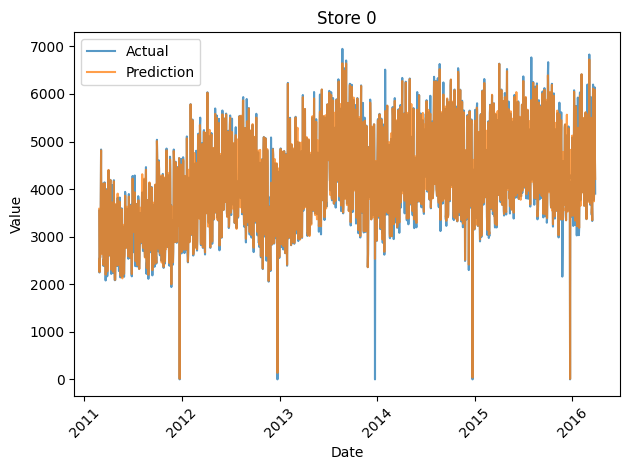

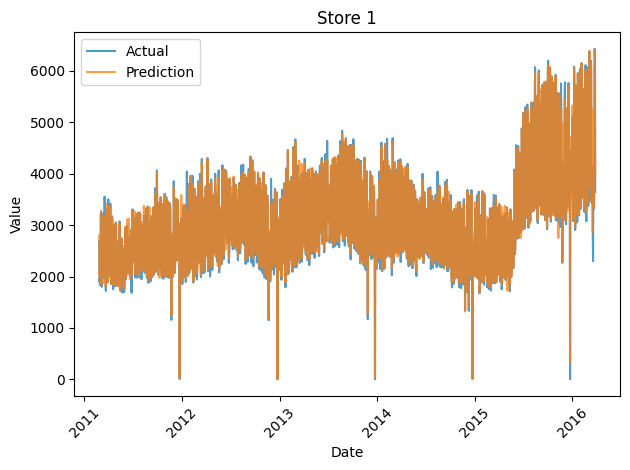

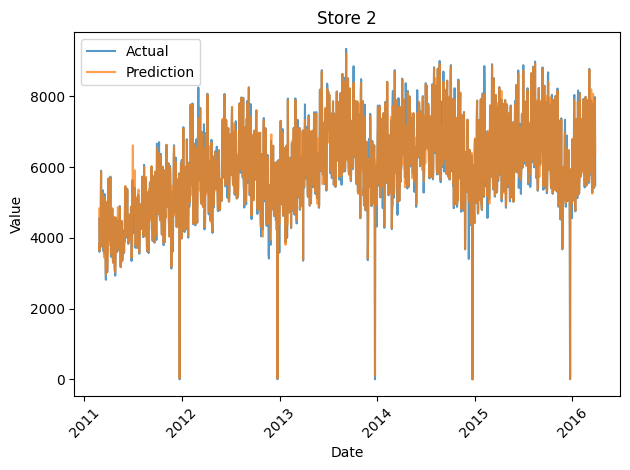

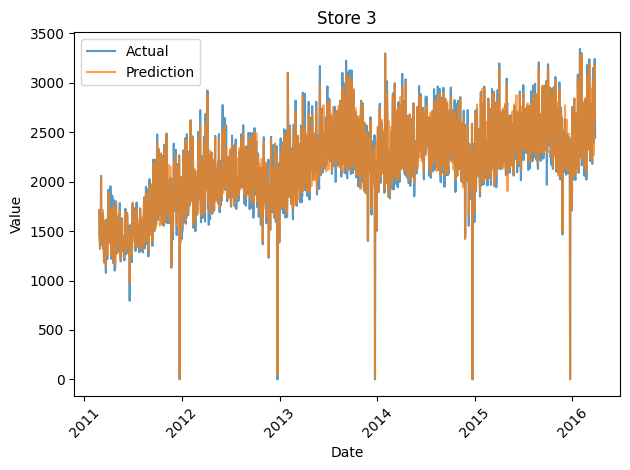

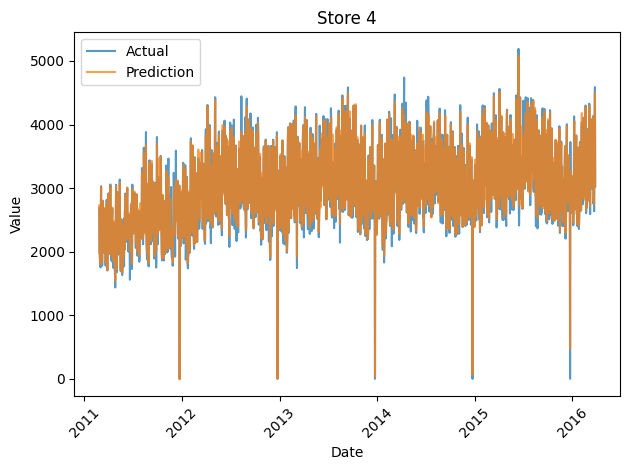

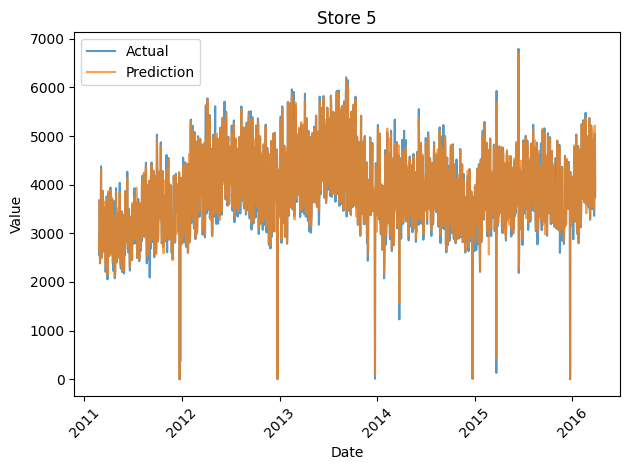

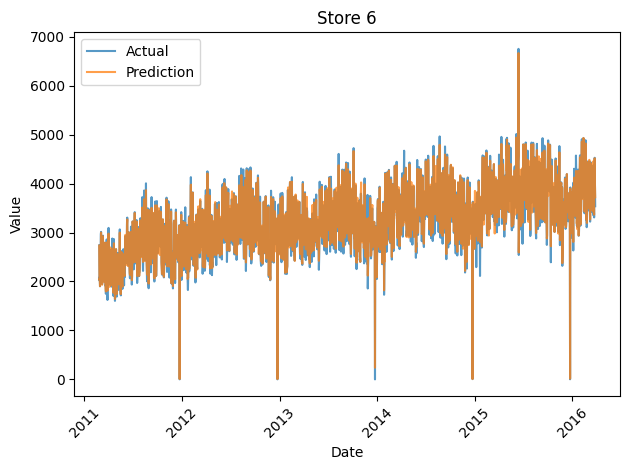

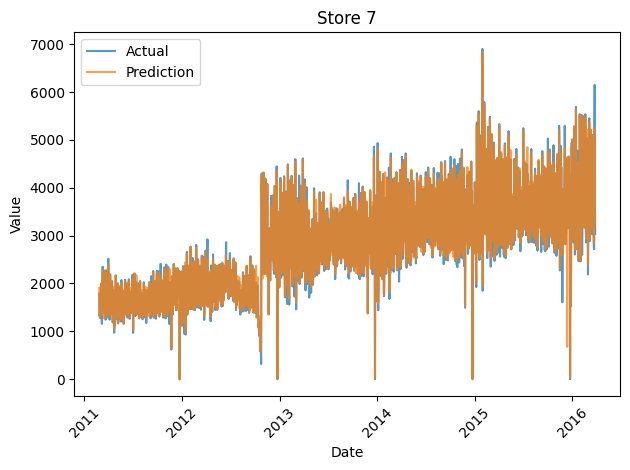

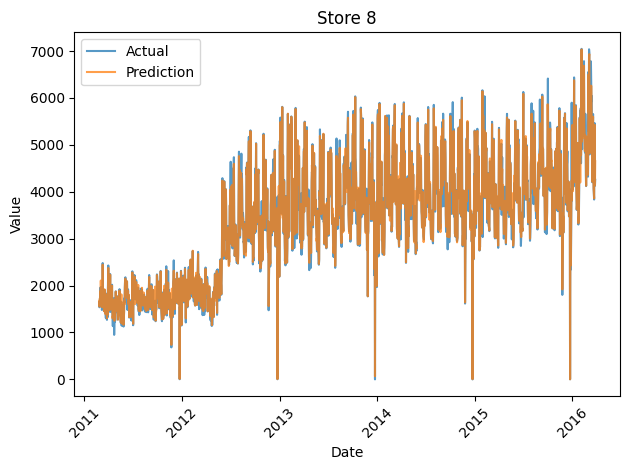

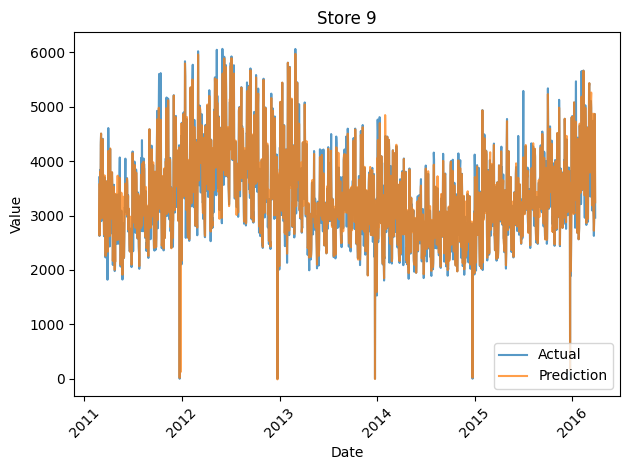

In [130]:
for store_id, df_store in dfs_by_store.items():
    plt.figure()
    
    plt.plot(df_store["date"], df_store["y_0"], label="Actual", alpha = 0.75)
    plt.plot(df_store["date"], df_store["ypred_0"], label="Prediction", alpha = 0.75)
    
    plt.title(f"Store {store_id}")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# 2016-04-24